<a href="https://colab.research.google.com/github/LongNguyen-code/BTVN-AI_CHIEUT2/blob/main/BTVN_FACE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
train_dir = "/content/drive/MyDrive/Ảnh F8 (1)"
img_width, img_height = 200,200
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode="categorical"
)

Found 237 images belonging to 7 classes.


In [35]:
import os

print(os.listdir("/content/drive/MyDrive/Ảnh F8 (1)"))

['Anh Thư', 'Trịnh Thị Kim Ngân', 'Lương Thị Như Bình', 'Nguyễn Hoàng Long (1)', 'Đào Ngọc Thi', 'Quế Phượng', 'Ngô Quỳnh Anh', 'my_face_model.h5', 'class_labels.pkl']


In [36]:
model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(img_width, img_height, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation="relu"),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(len(train_generator.class_indices),
      activation="softmax")
])

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 46, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 67712)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │     8,667,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,761,415 (33.42 MB)

 Trainable params: 8,761,415 (33.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.2869 - loss: 1.6298
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.4599 - loss: 1.2911
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.5738 - loss: 1.0194
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.6371 - loss: 0.8740
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.7089 - loss: 0.6976
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.7553 - loss: 0.5964
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.7806 - loss: 0.5723
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.8143 - loss: 0.5351
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.8059 - loss: 0.5020
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.8439 - loss: 0.4396
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.8439 - loss: 0.4495
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.8565 - loss: 0.3788
Epoch 13/50
8

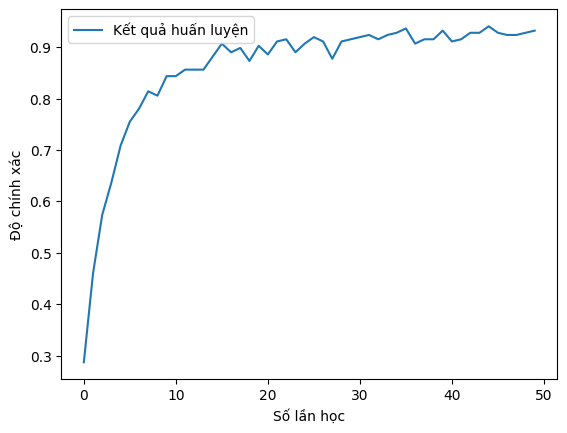

In [37]:
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])
model.summary()
epochs = 50
history = model.fit(train_generator, epochs=epochs)
plt.plot(history.history['accuracy'], label="Kết quả huấn luyện")
if 'val_accuracy' in history.history:
    plt.plot(history.history['val_accuracy'], label="Độ chính xác xác thực")

plt.xlabel("Số lần học")
plt.ylabel("Độ chính xác")
plt.legend()
plt.show()

In [38]:
model.save('/content/drive/MyDrive/model/face.h5')
print("Đã lưu model!")

Đã lưu model!


In [39]:
import pickle
import os

save_dir = '/content/drive/MyDrive/Ảnh F8 (1)'
os.makedirs(save_dir, exist_ok=True)

model_path = os.path.join(save_dir, 'my_face_model.h5')
label_path = os.path.join(save_dir, 'class_labels.pkl')

predictions = model.predict(img_array)
print(f"Đã lưu mô hình thành công vào: {model_path}")
print(f"Đã lưu nhãn thành công vào: {label_path}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step
Đã lưu mô hình thành công vào: /content/drive/MyDrive/Ảnh F8 (1)/my_face_model.h5
Đã lưu nhãn thành công vào: /content/drive/MyDrive/Ảnh F8 (1)/class_labels.pkl


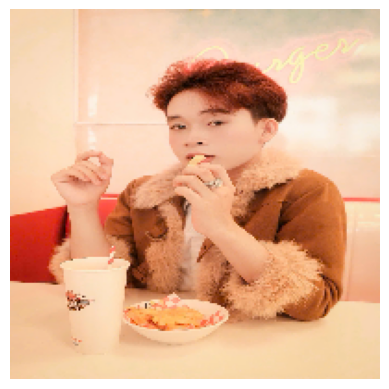

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step
Kết quả dự đoán: Anh Thư
Độ tin cậy: 73.20%


In [51]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array

MODEL_PATH = '/content/drive/MyDrive/model/face.h5'
IMAGE_PATH = "/content/z7888095347029_78f03df2e0a6ecf5164a875d6d0a62e9.jpg"

IMG_SIZE = (200,200)

model = load_model(MODEL_PATH)

# Lấy label từ train_generator
class_labels = {
    v: k for k, v in train_generator.class_indices.items()
}

img = load_img(IMAGE_PATH, target_size=IMG_SIZE)

plt.imshow(img)
plt.axis('off')
plt.show()

img_array = img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

predictions = model.predict(img_array)

prediction_idx = np.argmax(predictions)

person_name = class_labels[prediction_idx]

confidence = np.max(predictions) * 100

print(f"Kết quả dự đoán: {person_name}")
print(f"Độ tin cậy: {confidence:.2f}%")